<a href="https://colab.research.google.com/github/annaannaR/NOTEBOOKS-FROM-SCHOOL/blob/main/done/MLP3_4_Final_assignment_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Final assignment "Machine Learning met Python"

In this assignment you will:

* load a dataset
* prepare a machine learning model to make predictions
* train the model on the data and make predictions
* evaluate the predictions of the model

For the grading: each question shows how many points you can earn with it. You can earn 90 points, and an additional 10 points by also tackling the bonus question.

**Question 0. Prepare your notebook**

We start by preparing the notebook in two steps.

**a. Import pandas, numpy and matplotlib** (1 point)

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from matplotlib import pyplot as plt
#from tensorflow import keras
#from keras import layers, models, datasets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report
from sklearn.dummy import DummyClassifier

sns.set()

**b. Set a random seed so that your answers remain the same over different runs of your notebook** (1 point)

Choose a seed of 1234

In [52]:
np.random.seed(1234)

**Question 1. Prepare the dataset**

We will use a dataset stored in 'heart-disease.csv'. This dataset contains anonymous patient data and whether or not the patients have a heart condition.

The URL to get the data is: https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv

**a. Load the heart-disease dataset from the url** (1 point)

In [53]:
#df = pd.read_csv("heart-disease.csv")

df = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**b. Explore the dataset** (10 points)

Examine the dataset. Resolve any issues with missing values or incorrect data types. Also look at the distribution of the target column.

 - binary: sex, fbs, exang, target
- categorical: cp, restecg, slope, thal
- numeric: age, trestbps, chol, thalach, oldpeak, ca

In [54]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [56]:
df.sex = df.sex.astype(bool)
df.fbs = df.fbs.astype(bool)
df.exang = df.exang.astype(bool)
df.target = df.target.astype(bool)

categorical_columns = ['cp', 'restecg', 'slope', 'thal']
df[categorical_columns] = df[categorical_columns].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    int64   
 1   sex       303 non-null    bool    
 2   cp        303 non-null    category
 3   trestbps  303 non-null    int64   
 4   chol      303 non-null    int64   
 5   fbs       303 non-null    bool    
 6   restecg   303 non-null    category
 7   thalach   303 non-null    int64   
 8   exang     303 non-null    bool    
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        303 non-null    int64   
 12  thal      303 non-null    category
 13  target    303 non-null    bool    
dtypes: bool(4), category(4), float64(1), int64(5)
memory usage: 17.4 KB


<Axes: xlabel='target', ylabel='count'>

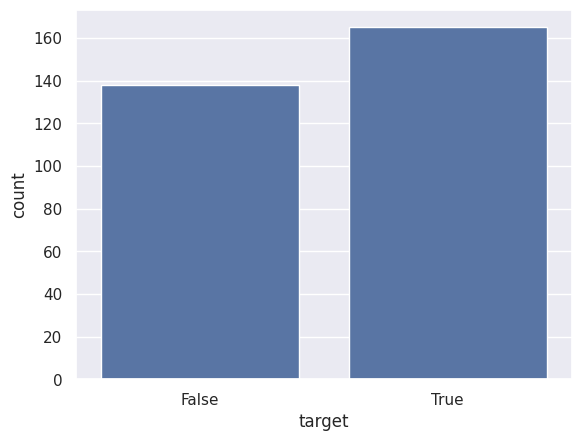

In [57]:
sns.countplot(data=df, x='target')

there is an even distribution, the number of observations of healthy and sick people is similar

**c. Explore the dataset using visualizations** (10 points)

For example, create a correlation matrix to explore the relationships between variables.

<Axes: >

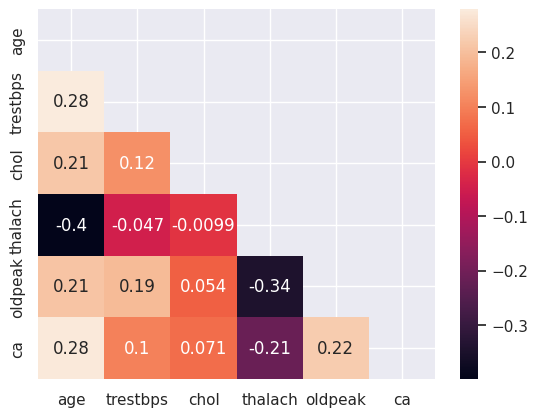

In [58]:
numeric_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
corr_matrix = df[numeric_columns].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, mask=mask)

In the case of thalach, we can observe a negative correlation between age and maximum heart rate.

Oldpeak and thalach are negatively correlated.

Age - is correlated with each of the variables - each of these variables contains some information about age; perhaps age is unnecessary.

It's worth checking the correlations with and without age to see how it behaves.

Ask why I didn't receive a description of this data. Draw conclusions without a business description.

**Question 2. Prepare your dataset for analysis**

Now that we have cleaned up the data and better understand it, let's prepare the dataset for analysis.

**Question 2a. Split the dataframe into features and target** (5 points)

Our goal is to train a machine learning model on the independent variables/features (you can choose all features or a selected set), with the aim of predicting the target (in this case the target column is also conveniently called "target").


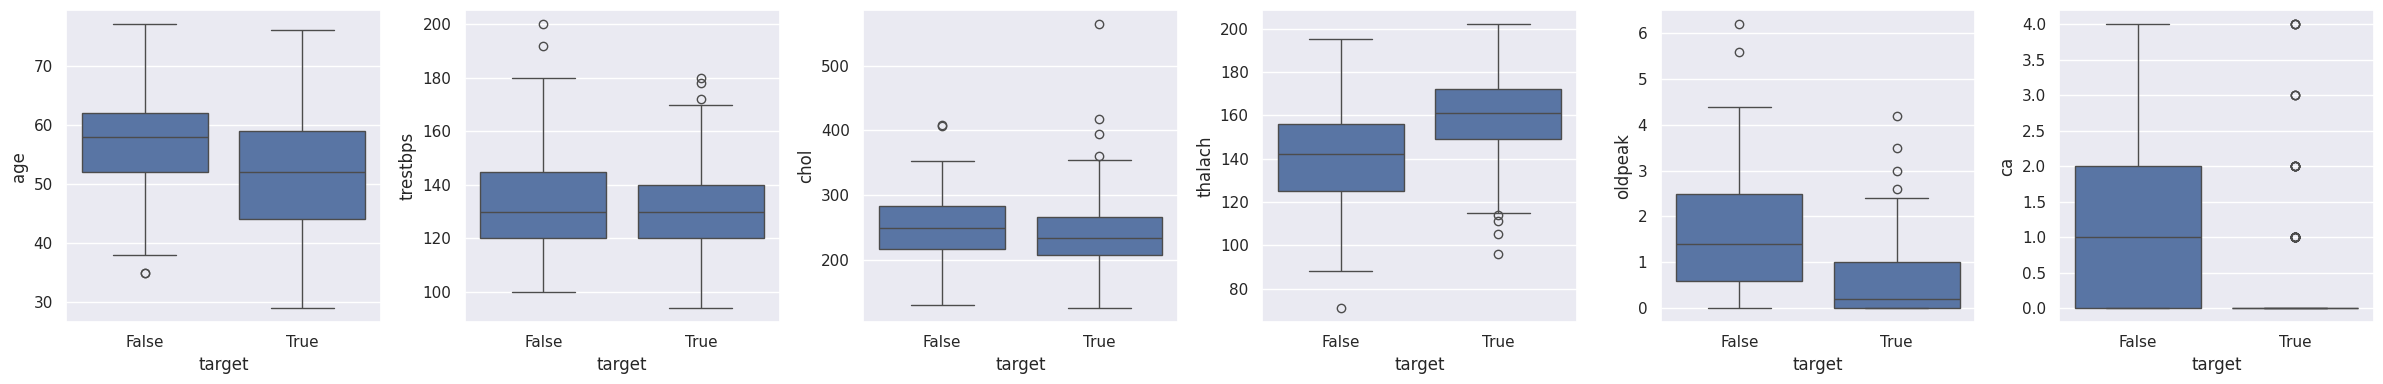

In [59]:
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(24,4))

for ax, col in zip(axes, numeric_columns):
    sns.boxplot(data=df, x='target', y=col, ax=ax)

plt.tight_layout()

The median age among individuals with the disease is lower than the median age among healthy individuals.

The most important features are thalach, oldpeak, and ca, as they demonstrate clear distinctions between classes of the target variable. Variables such as chol and trestbps do not provide strong discrimination.

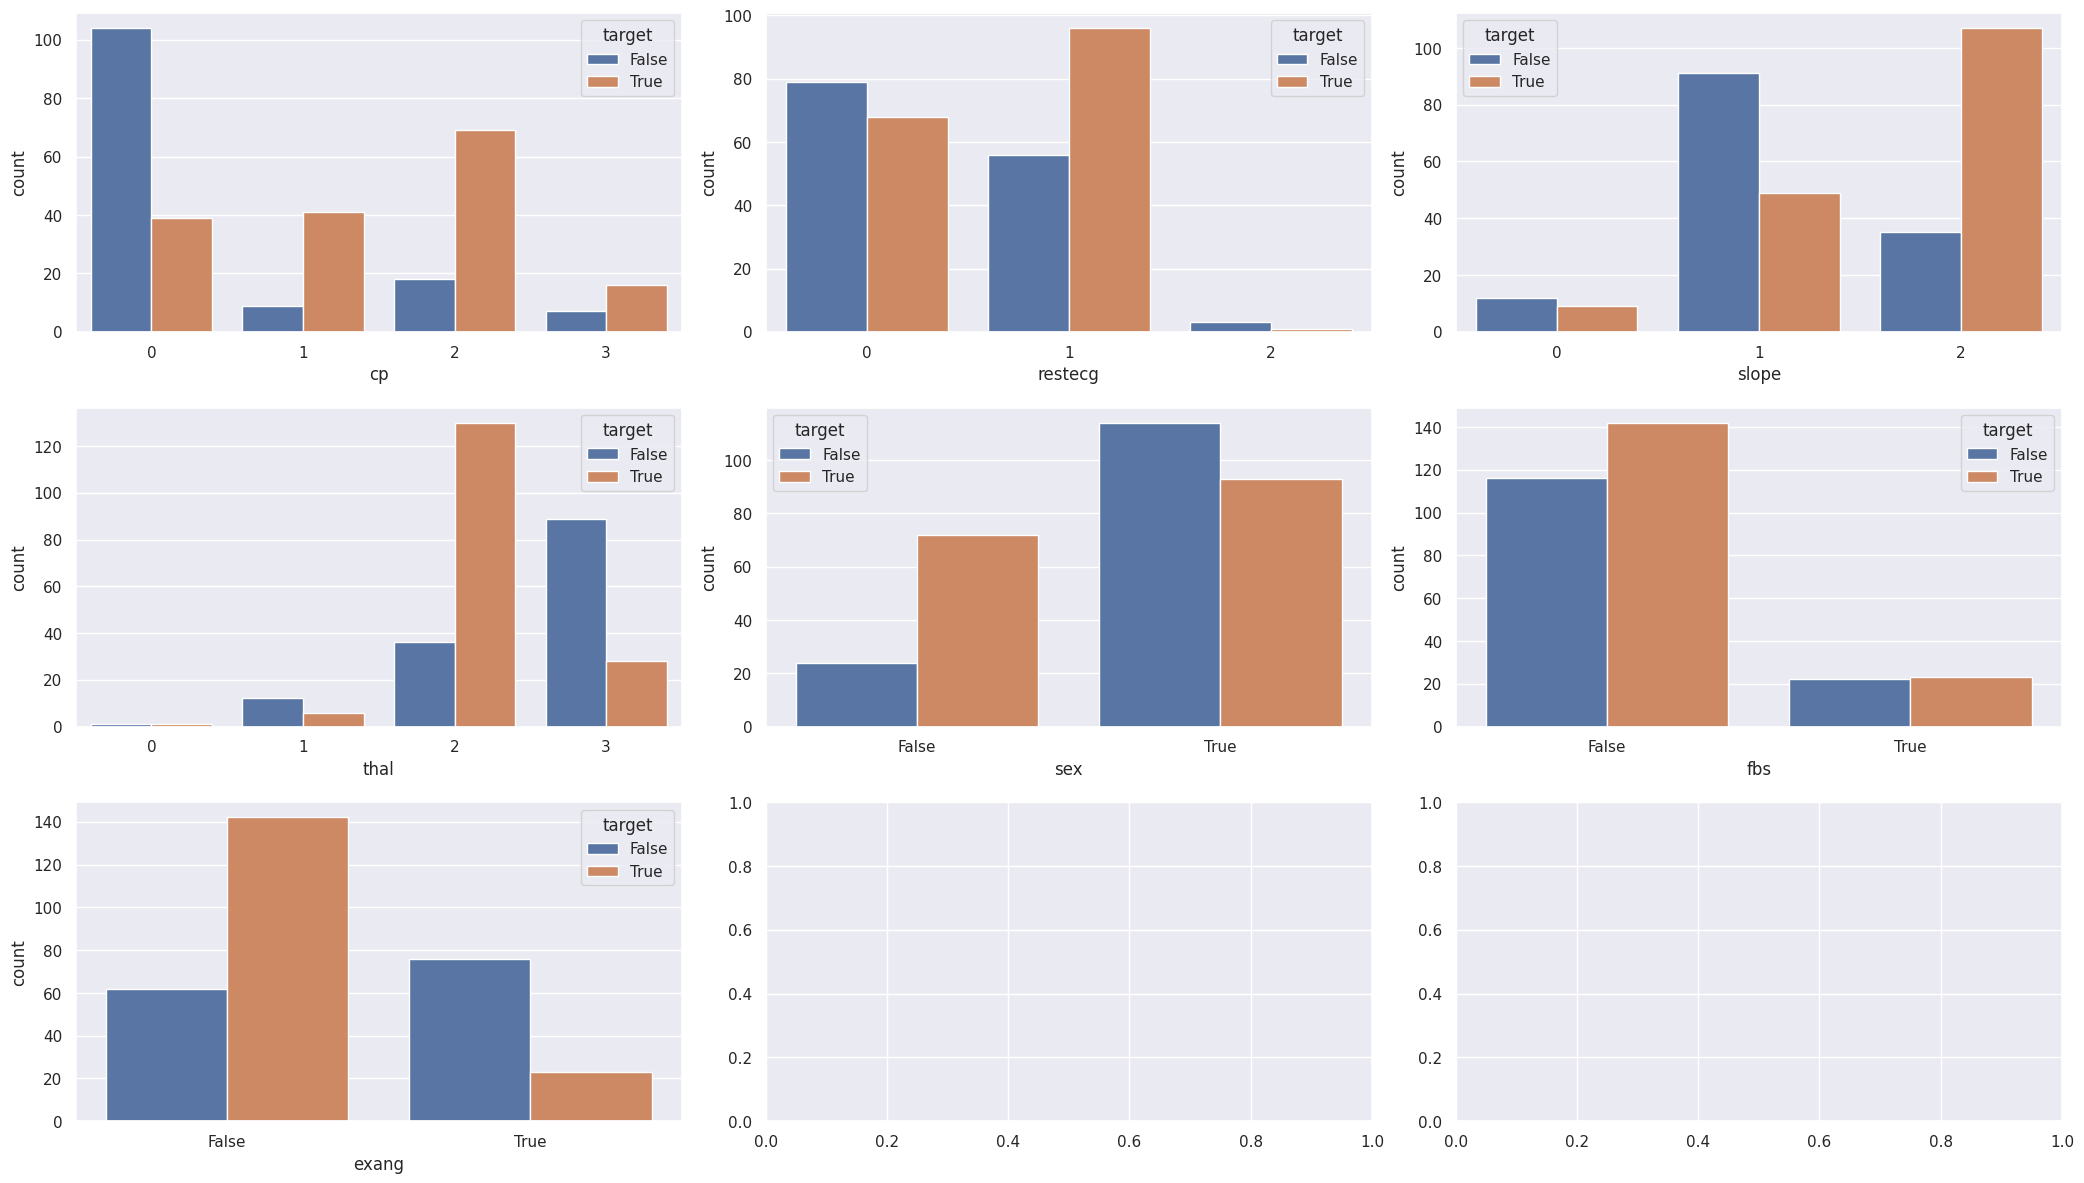

In [60]:
categorical_and_binary_columns = ['cp', 'restecg', 'slope', 'thal', 'sex', 'fbs', 'exang']

fig, axes = plt.subplots(3, 3, figsize=(21,12))
axes=axes.flatten()

for ax, col in zip(axes, categorical_and_binary_columns):
    sns.countplot(data=df, hue='target', x=col, ax=ax)

plt.tight_layout()

restcg - can stay, fbs - should be rejected, does not translate into target

**Question 2b. Split the data into a training set and a test set** (5 points)

Use a split of 70% train and 30% test.

In [61]:
y = df['target']
X = df.drop('target', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

**Question 3. Train a prediction model** (10 points)

Think of what kind of prediction-problem we are dealing with, and choose a model accordingly.

binary classification problem

In [62]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [63]:
decision_tree = DecisionTreeClassifier(max_depth=7)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7)

[Text(0.5675675675675675, 0.9375, 'x[2] <= 0.5\ngini = 0.497\nsamples = 212\nvalue = [98, 114]'),
 Text(0.2972972972972973, 0.8125, 'x[11] <= 0.5\ngini = 0.387\nsamples = 103\nvalue = [76, 27]'),
 Text(0.43243243243243246, 0.875, 'True  '),
 Text(0.21621621621621623, 0.6875, 'x[12] <= 2.5\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.13513513513513514, 0.5625, 'x[8] <= 0.5\ngini = 0.4\nsamples = 29\nvalue = [8, 21]'),
 Text(0.05405405405405406, 0.4375, 'x[7] <= 96.5\ngini = 0.198\nsamples = 18\nvalue = [2, 16]'),
 Text(0.02702702702702703, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.08108108108108109, 0.3125, 'x[4] <= 300.5\ngini = 0.111\nsamples = 17\nvalue = [1, 16]'),
 Text(0.05405405405405406, 0.1875, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.10810810810810811, 0.1875, 'x[3] <= 135.0\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.08108108108108109, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.13513513513513514, 0.0625, 'gin

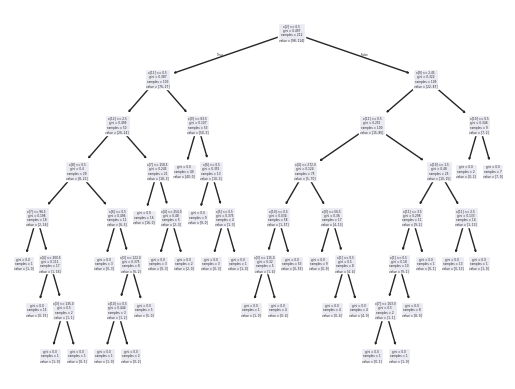

In [64]:
plot_tree(decision_tree)

**Question 4. Generate your predictions** (10 points)

In [65]:
# save the predictions in a variable called y_preds

y_preds = decision_tree.predict(X_test)

**Question 5. Evaluate your model against a baseline** (12 points)

In [66]:
# Compare the results to the results of a benchmark/baseline (use a dummy)
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

       False       0.68      0.75      0.71        40
        True       0.79      0.73      0.76        51

    accuracy                           0.74        91
   macro avg       0.73      0.74      0.73        91
weighted avg       0.74      0.74      0.74        91



In [67]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

In [68]:
print(classification_report(y_test, y_pred_dummy))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00        40
        True       0.56      1.00      0.72        51

    accuracy                           0.56        91
   macro avg       0.28      0.50      0.36        91
weighted avg       0.31      0.56      0.40        91



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Question 6. What are your conclusions about the performance of the model you trained?** (15 points)

How well did your model perform?

What metrics did you use to evaluate your model? And what do these statistics say?

Type your answer here:


The first model performs much better than the dummy model, characterized by similar metric values ​​for both classes (F1, recall). Precision for the False class is much lower than for the True class, and accuracy is quite good.

We use precision, the ratio of true positive to all positives classified. Recall - true positive / false negative + true positive - for all observations that fall into this class. F1-score - a summary metric (harmonic mean of precision and recall).

Accuracy - the percentage of correctly classified information.

**Bonus question. Try improving your performance scores by either optimizing the hyperparameters, or training another kind of model** (10 points)

In [69]:
y = df['target']
X = df.drop('target', axis = 1)

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8131868131868132
              precision    recall  f1-score   support

       False       0.76      0.85      0.80        41
        True       0.87      0.78      0.82        50

    accuracy                           0.81        91
   macro avg       0.81      0.82      0.81        91
weighted avg       0.82      0.81      0.81        91



I tried a different model – Gradient Boosting. I slightly adjusted the parameters like number of estimators and depth. The model achieved better results than the baseline, which shows that choosing a different algorithm can improve performance.